In [18]:
import tensorflow as tf
import numpy as np
import pandas as pd

from keras.optimizers import Adam
from keras import Sequential, Model
from keras.layers import Dense, Input
from scikeras.wrappers import KerasClassifier, KerasRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sb

matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False


## 과제(low, high)
- 피마인디안
- train,test
- 정규화
- 딥러닝
- train,test 정확도, f1, confusion matrix
- train 1,2 예측값

In [2]:
df=pd.read_csv('../data/pima-indians-diabetes.data.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
x_data=df.iloc[:,:-1]
y_data=df.iloc[:,-1]

In [4]:
x_train,x_test,y_train,y_test=train_test_split(
    x_data,
    y_data,
    stratify=y_data,
    random_state=42
)

In [5]:
stand=StandardScaler()
x_train_scaled=stand.fit_transform(x_train).astype('float32')
x_test_scaled=stand.transform(x_test).astype('float32')
y_train=pd.DataFrame(y_train).values.astype('float32')
y_test=pd.DataFrame(y_test).values.astype('float32')


LOW

In [ ]:
initX = tf.initializers.GlorotUniform() 
w2 = tf.Variable( initX( shape=[8,30] ) )
w1 = tf.Variable( initX( shape=[30,1] ) )
b2 = tf.Variable( initX( shape=[30] ) )
b1 = tf.Variable( initX( shape=[1] ) ) 

In [22]:
lr = 0.001
optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
for i in range(3000):
    with tf.GradientTape() as tape:
        z1 = tf.matmul(x_train_scaled,w2) + b2
        a1 = tf.nn.relu(z1)
        z2=tf.matmul(a1,w1)+b1
        cost_i = tf.nn.sigmoid_cross_entropy_with_logits(labels=y_train, logits=z2)
        cost = tf.reduce_mean( cost_i)
    
    gradients = tape.gradient(cost, [w2, b2, w1, b1])
    optimizer.apply_gradients(zip(gradients, [w2, b2, w1, b1]))
    print( 'cost', cost.numpy())    

print('최종w', w2.numpy() )
print('최종b', b2.numpy() )

cost 0.3038768
cost 0.30383873
cost 0.30367655
cost 0.30350173
cost 0.30333412
cost 0.30318868
cost 0.3030373
cost 0.3028892
cost 0.30274186
cost 0.30259144
cost 0.3024335
cost 0.30228674
cost 0.302146
cost 0.3020027
cost 0.30185091
cost 0.30169567
cost 0.30153728
cost 0.3013843
cost 0.3012305
cost 0.30107132
cost 0.30091488
cost 0.30075797
cost 0.30060223
cost 0.30044794
cost 0.30029392
cost 0.30013117
cost 0.29997286
cost 0.29981497
cost 0.29966018
cost 0.29950464
cost 0.29934567
cost 0.29918915
cost 0.2990309
cost 0.2988713
cost 0.29871464
cost 0.29856092
cost 0.29840434
cost 0.29824853
cost 0.29809582
cost 0.2979442
cost 0.29779303
cost 0.29764372
cost 0.29748815
cost 0.29733384
cost 0.2971854
cost 0.2970327
cost 0.29688045
cost 0.29672995
cost 0.29657808
cost 0.2964253
cost 0.2962737
cost 0.29612073
cost 0.29596892
cost 0.29581892
cost 0.29567423
cost 0.29552236
cost 0.29537615
cost 0.29523194
cost 0.2950865
cost 0.29493985
cost 0.29479572
cost 0.29464993
cost 0.29450414
cost 0.29

In [17]:
def hxfn(x):
    z1 = tf.matmul(x, w2) + b2
    a1 = tf.nn.relu(z1)
    z2 = tf.matmul(a1, w1) + b1
    return (tf.sigmoid(z2).numpy() > 0.5).astype('float32')


In [23]:
train_pred=hxfn(x_train_scaled)
test_pred=hxfn(x_test_scaled)

train f1 : 0.9961791044776119
test f1 : 0.6953125
train 정확도 : 0.9965277777777778
test 정확도 : 0.7291666666666666


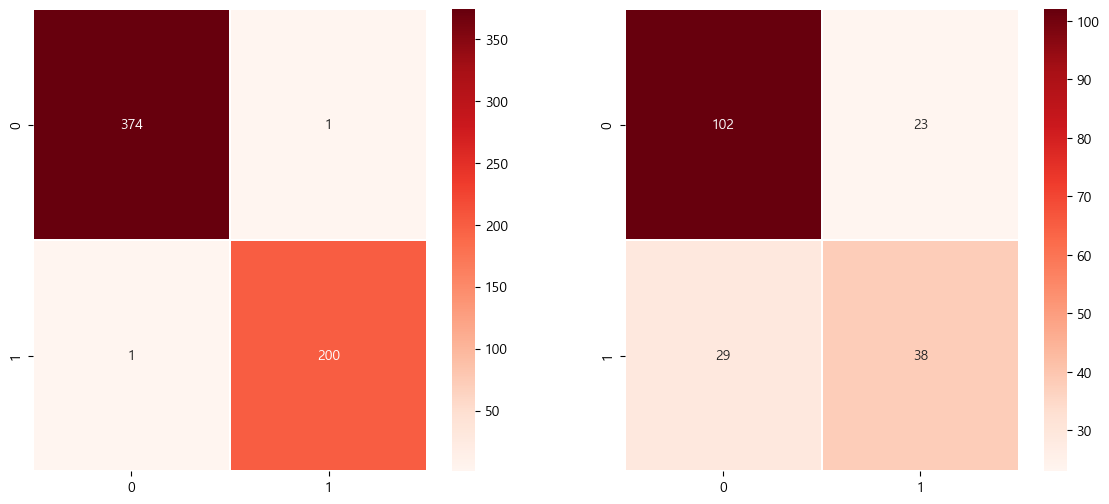

In [24]:
plt.figure(figsize=(14, 6))
c=confusion_matrix(y_train, train_pred)
plt.subplot(1,2,1)
sb.heatmap( c, 
           annot=True, 
           fmt='d',
           linewidths=0.2, 
           cmap='Reds',
           )


c=confusion_matrix(y_test, test_pred)
plt.subplot(1,2,2)
sb.heatmap( c, 
           annot=True, 
           fmt='d',
           linewidths=0.2, 
           cmap='Reds',
           )

print("train f1 :", f1_score(y_train, train_pred, average="macro"))
print("test f1 :", f1_score(y_test, test_pred, average="macro"))
print("train 정확도 :", accuracy_score(y_train, train_pred))
print("test 정확도 :", accuracy_score(y_test, test_pred))

HIGH

In [86]:
class Mymodel( Model):
    def __init__(self):
        super( Mymodel, self).__init__()
        self.dense1 = Dense( units=16, activation='relu')
        self.dense2 = Dense( units=8, activation='relu')
        self.dense3 = Dense( units=1, activation='sigmoid')

    def call(self, inputs):
        hx1 = self.dense1(inputs)
        hx2 = self.dense2(hx1)
        return self.dense3(hx2)

In [87]:
model = Mymodel()
model.compile(loss='binary_crossentropy',optimizer=Adam(0.001),metrics=['acc'])
h = model.fit(x_train_scaled, y_train, epochs=800)

Epoch 1/800
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.4861 - loss: 0.6896  
Epoch 2/800
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.6285 - loss: 0.6693 
Epoch 3/800
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.6806 - loss: 0.6539 
Epoch 4/800
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.6892 - loss: 0.6395 
Epoch 5/800
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.6997 - loss: 0.6240 
Epoch 6/800
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7101 - loss: 0.6085 
Epoch 7/800
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7257 - loss: 0.5919 
Epoch 8/800
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7309 - loss: 0.5743 
Epoch 9/800
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7378 - loss: 0.5589 
Epoch 10/800
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7465 - loss: 0.5434 
Epoch 11/800
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7517 - loss: 0.5304 
Epoch 12/800
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7552 - loss: 0.5177 
Epoch 13/800
18/18 ━━━━━

In [84]:
train_pred=(model.predict(x_train_scaled)>0.5)+0
test_pred=(model.predict(x_test_scaled)>0.5)+0

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


train f1 : 0.9407074856135295
test f1 : 0.6879340406040368
train 정확도 : 0.9461805555555556
test 정확도 : 0.7135416666666666


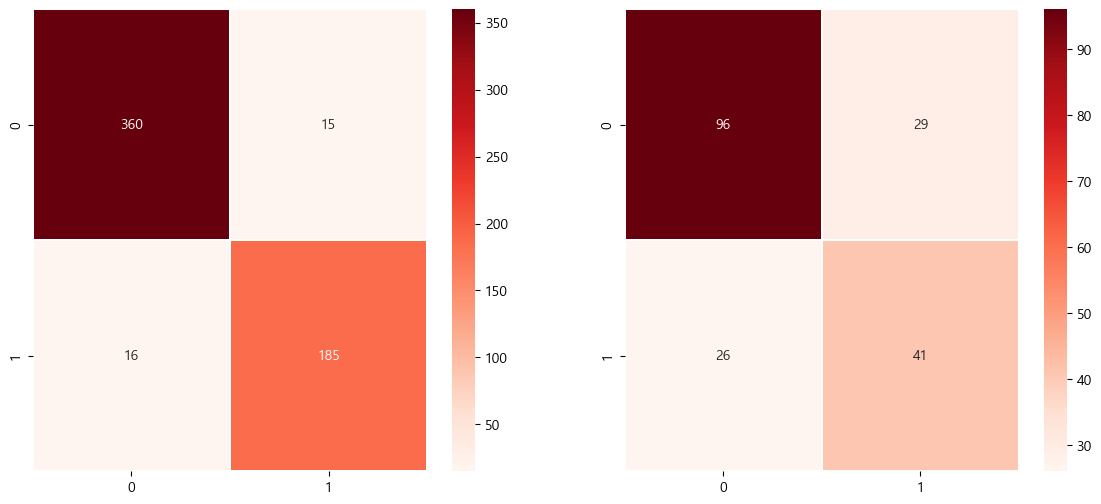

In [88]:
plt.figure(figsize=(14, 6))
c=confusion_matrix(y_train, train_pred)
plt.subplot(1,2,1)
sb.heatmap( c, 
           annot=True, 
           fmt='d',
           linewidths=0.2, 
           cmap='Reds',
           )


c=confusion_matrix(y_test, test_pred)
plt.subplot(1,2,2)
sb.heatmap( c, 
           annot=True, 
           fmt='d',
           linewidths=0.2, 
           cmap='Reds',
           )

print("train f1 :", f1_score(y_train, train_pred, average="macro"))
print("test f1 :", f1_score(y_test, test_pred, average="macro"))
print("train 정확도 :", accuracy_score(y_train, train_pred))
print("test 정확도 :", accuracy_score(y_test, test_pred))

In [93]:
model.predict(x_train_scaled[:2])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


array([[0.07718732],
       [0.07480875]], dtype=float32)